In [284]:
using Pkg; Pkg.activate("$(ENV["DIVA_LIB"])"); include("$(ENV["DIVA_LIB"])/src/DIVACoast.jl"); using .DIVACoast # Load DIVACoast package
using Plots; using GeoArrays; using Statistics; using CSV; using DataFrames; using Test # Additional required packages
using Logging; global_logger(DIVACoast.DIVALogger()) # Use DIVACoast custom logger

  Activating project at `C:\Users\Lars\Work\Global_Climate_Forum\DIVA\DIVACoast`


┌                                       ┐
│ DIVACoast.jl | © GLOBAL CLIMATE FORUM │
└                                       ┘


Main.DIVACoast.DIVALogger(VSCodeServer.IJuliaCore.IJuliaStdio{Base.PipeEndpoint, typeof(VSCodeServer.io_send_callback)}(IOContext(Base.PipeEndpoint(Base.Libc.WindowsRawSocket(0x0000000000000334) open, 0 bytes waiting)), VSCodeServer.io_send_callback), Info, "DIVACoast", Dates.DateTime("2025-11-25T14:50:12.200"))

In [3]:
# Set universal path to data
data_path = subdir -> "$(ENV["DIVA_DATA"])/the_wash_testdata/$(subdir)"

#17 (generic function with 1 method)

# Data Pipeline

## Load Datasets

All required datasets are loaded as GeoArray. The required datasets are: 

1. **Elevation:** A digital elevation model providing an elevation value for each pixel within the region of interest. Here we use the FABDEM.
2. **Water Bodies:** A mask defining ocean, land, and river pixel. Here we use the Copernicus Water Body Mask.
3. **Land Cover:** A landcover datsets, to be transformed into local attenuation rates.
4. **Population:** In this example we want to calculate exposed population, therfore we require a population dataset, here `worldpop`
5. **Attenuation rate mapping:** A lookup table to map landcover classes (from 3) to attenuation rates
4. **Region of interest:** A binary mask, defining the region of interest (1).

In [70]:
elevation = data_path("fabdem.tif") |> GeoArrays.read
water_bodies = data_path("wbm.tif") |> GeoArrays.read
landcover = data_path("corine.tif") |> GeoArrays.read |> x -> convert.(Float32, x)
population = data_path("worldpop.tif") |> GeoArrays.read
att_rate_mapping = data_path("corine_attr_mapping.csv") |> CSV.File |> DataFrame
#fp_63840_mask = data_path("fp_63840_mask.tif") |> GeoArrays.read # Floodplain mask (not used here)

@info "Loaded input datasets"

┌ DIVACoast|Info @12:00:43(after 1 minute, 26 seconds, 952 milliseconds)
└ Loaded input datasets


## Pre-processing
### 1. Sanity check
Lets do a small sanity check to ensure all input files:
    - have the same dimensions
    - have the same datatype (Float32)
    - all classes in the landcover datasets have an associated attenuation rate in the mapping

In [ ]:
# Small Sanity check for input data
testresult = @testset "Input Data Sanity Check" begin
    @test size(elevation ) == size(water_bodies) == size(landcover) == size(population) # All input datasets have the same dimensions
    @test eltype.([elevation, landcover, population])  |> x -> all(==(Float32), x) # All relevant datasets are Float32
    @test setdiff(unique(landcover), (att_rate_mapping[!, :class_code] |> x -> convert.(eltype(x), x))) |> isempty # All landcover classes are mappable
end

Test Summary:           | Pass  Total  Time
Input Data Sanity Check |    3      3  0.1s


Test.DefaultTestSet("Input Data Sanity Check", Any[], 3, false, false, true, 1.76407119287e9, 1.764071192986e9, false, "c:\\Users\\Lars\\Work\\Global_Climate_Forum\\DIVA\\DIVACoast\\notebooks\\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X30sZmlsZQ==.jl")

Since not all input files have the same spatial resoultion (see dimension mismatch) we can use the following `resampling` function to perform nearest neighbour resampling

In [174]:
function resample(ref_raster, src_raster) 

    # Check if resampling is needed
    size(ref_raster) == size(src_raster) && return src_raster # No resampling needed

    # Get target and source dimensions
    target_width, target_height = size(ref_raster)
    source_width, source_height = size(src_raster)

    # Calculate scaling factors
    x_scale = source_width / target_width
    y_scale = source_height / target_height

    # Initialize resampled data array
    resampled_data = Array{eltype(src_raster)}(undef, target_width, target_height)

    for i in 1:target_width
        for j in 1:target_height
            
            # Map target coordinate to source coordinate space
            src_x = clamp(round(Int, i * x_scale), 1, source_width)
            src_y = clamp(round(Int, j * y_scale), 1, source_height)
            
            # Assign value from the nearest neighbor in the source raster
            resampled_data[i, j] = src_raster[src_x, src_y]
        end
    end
    return GeoArrays.GeoArray(resampled_data, ref_raster.f, ref_raster.crs)
end

population = resample(elevation, population)
@info "Resampled population dataset to match elevation dataset dimensions"

┌ DIVACoast|Info @12:50:57(after 49 minutes, 41 seconds, 568 milliseconds)
└ Resampled population dataset to match elevation dataset dimensions


Plot the result

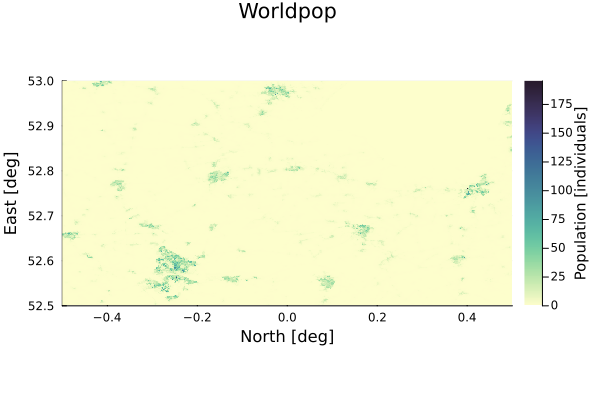

In [173]:
heatmap(population_resampled; c = :deep,  title="Worldpop", xlabel="North [deg]", ylabel="East [deg]", colorbar_title="Population [individuals]")

### 2. Derrive river beds

Since the `FABDEM` product does not contain "river beds", elevation data for rivers, we derrive the elevation from the surrounding area by applying a radial cursor around each "river pixel" according to the `Copernicuse Water Bodies Mask`

In [ ]:
# Lookup for the water body classes
water_body_classes = Dict(
    "no_water" => 0.0,
    "ocean" => 1.0,
    "lake" => 2.0,
    "river" => 3.0)

In [65]:
# Modification of the elevation data to derrive river bed elevations

# Set river pixels to `nothing`
elevation[water_bodies .== water_body_classes["river"]] .= 0.0 # Ensure river pixels are zero for the mean calculation

# Define the spatial cursor
cursor = DIVACoast.SpatialCursorRadial(3) # 3 pixel radius around each pixel the cursor is applied to

# Pipeline to derrive elevation from neighboring pixels (not being river nor no_data / nothing)
riverelevation = (idx, elev, c) -> DIVACoast.nbvalues(elev, idx; cursor = c) |> x -> filter(!iszero, x) |> isempty ? 0.0 : mean(x)

# Get all river pixel indices
riverpx = findall(water_bodies .== water_body_classes["river"])

# Map the river bed pipeline to each river pixel
map(eachindex(riverpx)) do i
    elevation[riverpx[i]] = riverelevation(riverpx[i], elevation, cursor)
end

@info "Derrived river bed elevations"

┌ DIVACoast|Info @11:59:31(after 15 seconds, 893 milliseconds)
└ Derrived river bed elevations


Plot the result

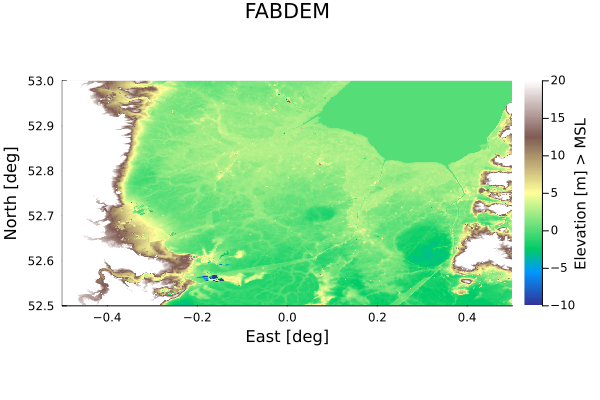

In [37]:
heatmap(elevation; c = cgrad(:terrain) , clims = (-10, 20), title = "FABDEM", xlabel = "East [deg]", ylabel = "North [deg]", colorbar_title = "Elevation [m] > MSL")

### 3. Land Cover to attenuation rates

For the `PathBasedAttenuatedBathtub` model we want to test local attenuation rates according to the underlying landcover class, therfore we need to assign an attenuation rate
to the associated landcover class within the landcover datasets (here Corine). 

In [182]:
# Reclassfication pipeline to assign attenuation rates to landcover classes
reclass_landcover = (lc, lc_class, attrate) -> lc[lc .== lc_class] .= attrate

# Assign attenuation rates to all landcover classes in the mapping file
attrates = deepcopy(landcover)
map(eachrow(att_rate_mapping)) do row
    reclass_landcover(attrates, row.class_code, row.attenuation_rate)
end

@info "Assigned attenuation rates according to landcover classes"

┌ DIVACoast|Info @12:52:38(after 51 minutes, 22 seconds, 39 milliseconds)
└ Assigned attenuation rates according to landcover classes


Plot the result

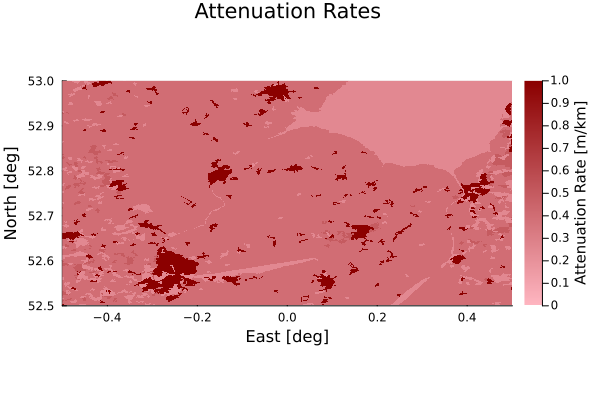

In [183]:
heatmap(attrates; c = cgrad(:reds) , clims = (0, 1), title = "Attenuation Rates", xlabel = "East [deg]", ylabel = "North [deg]", colorbar_title = "Attenuation Rate [m/km]")

## Initialize the SpatialProfile

After pre-processing we can define our `SpatialProfile`. This datatype holds the elevation data and our exposure variables (here population). A `SpatialProfile` also requires information on where the ocean and where the coast is, therfore we provide it with a ´SpatialProfileMask` derrived from the Copernicus Water Body Mask.

In [303]:
# First the mask, based on the water bodies dataset
spatial_mask = DIVACoast.SpatialProfileMask(water_bodies, water_body_classes["ocean"])

<DIVACoast.jl | SpatialProfileMask | 3712x1856>

In [304]:
# Define the SpatialProfile
spatial_profile = DIVACoast.SpatialProfile(elevation, mask = spatial_mask, exposures = [population])

<DIVACoast.jl | SpatialProfile | 3712x1856>

plot the profile

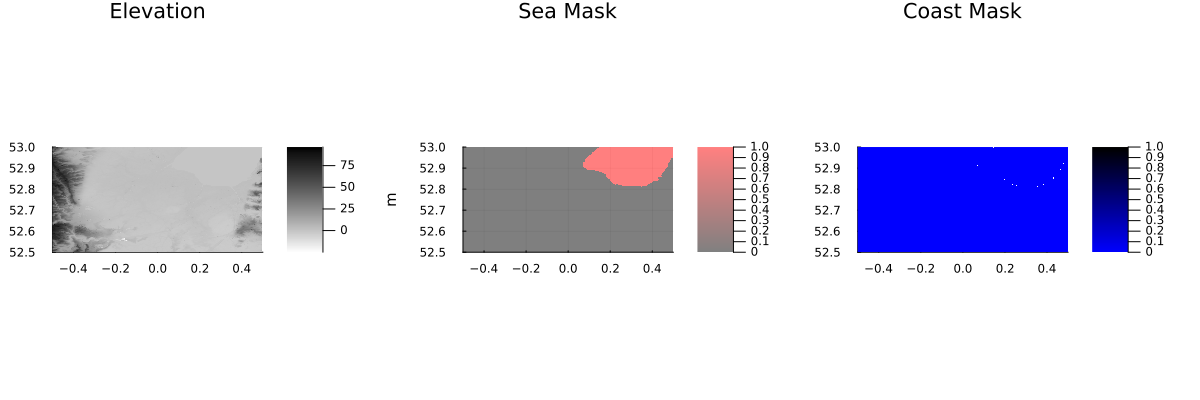

In [285]:
plot(spatial_profile)

## Model setup / scenario definition

Finally, we can setup the models we want to test and the water levels we want to calculate inundaiton for within our target region.

In [ ]:
models = Dict(
    "HCB" => DIVACoast.HydraulicConnectedBathtub(),
    "PBAB_G" => DIVACoast.PathBasedAttenuatedBathtub(0.2), 
    "PBAB_L" => DIVACoast.PathBasedAttenuatedBathtub(attrates)
)

water_levels = 0.5:0.5:5.0

0.5:0.5:5.0

## Calculate inundation

Let's start the computation! The results will be stored in a Dict mapping "model name" to an Vector of inundation depths assosciated with a certain water level.

**Disclaimer: This will take ~20min! For testing you can run inundation for specific scenarios, like:**

```julia
inundation = DIVACoast.inundate(spatial_profile, 1.0, DIVACoast.HydraulicConnectedBathtub())
```

In [ ]:
# Run the inundation for all models and water levels
results = Dict(
    model_name => map(wl -> DIVACoast.inundate(spatial_profile, wl, models[model_name]), water_level) for model_name in keys(models)
)


Dict{String, Vector} with 3 entries:
  "PBAB_L" => Matrix{Float32}[[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; Inf In…
  "HCB"    => [[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; Inf Inf … 0.0 0.0; In…
  "PBAB_G" => Matrix{Float32}[[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; Inf In…

# Display results

For export you can convert the results into a `GeoArray`

In [249]:
to_ga = (inun_arr, profile) -> GeoArrays.GeoArray(inun_arr, profile.elevation.f, profile.elevation.crs)

result_ga = Dict(
    model_name => map(inun -> to_ga(inun, spatial_profile), results[model_name]) for model_name in keys(results)
)

Dict{String, Vector} with 3 entries:
  "PBAB_L" => GeoArray{Float32, 2, Matrix{Float32}}[3712x1856 Matrix{Float32} w…
  "HCB"    => GeoArray{Float64, 2, Matrix{Float64}}[3712x1856 Matrix{Float64} w…
  "PBAB_G" => GeoArray{Float32, 2, Matrix{Float32}}[3712x1856 Matrix{Float32} w…

For displaying, you can make an animation like:

Plots.AnimatedGif("C:\\Users\\Lars\\AppData\\Local\\Temp\\jl_ruzcJMxGda.gif")
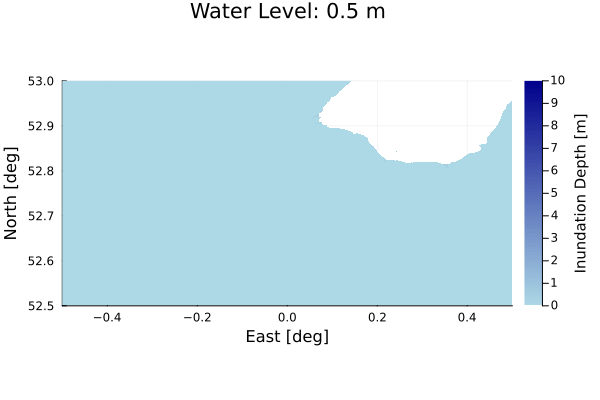

In [318]:
plot_params = Dict(
    :c => cgrad(:blues),
    :clims => (0, 10), 
    :xlabel => "East [deg]",
    :ylabel => "North [deg]",
    :colorbar_title => "Inundation Depth [m]",
    :aspect_ratio => :equal
)



# Define the animation function
create_anim = (inun_arr) -> @animate for (i, inun) in enumerate(inun_arr)
    heatmap(inun; plot_params..., title = "Water Level: $(water_levels[i]) m")
end

create_anim(result_ga["PBAB_L"]) |> p -> gif(p, fps = 2)